## Hurst Exponent and Generalized Scaling Exponent for Pressure and Temperature

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.io import loadmat
from typing import Tuple
from Minimum_Variance_Index import Scaling_Exponents
from Interval_Halving import Modified_Interval_Halving
import matplotlib.pyplot as plt

## Computing MVI (Generalized Scaling Exponent) for Pressure variables
## For Original time series vs Segmented time series (using Interval Halving)

In [3]:
location = 'Pressure_data.xlsx'
sheet_to_df_map = pd.read_excel(location, sheet_name = None)

In [4]:
col_names = ['PSPCKL', 'PSPCKR', 'PSPCKOU']
count = 1
alpha_cols_orig, eta_cols_orig = dict(), dict()
alpha_cols_pred, eta_cols_pred = dict(), dict()

# Optimal parameters determined manually from the plots
frac_pspckl = [0.061, 0.087, 0.14, 0.11, 0.087, 0.061, 0.11, 0.139, 0.11, 0.087, 0.087, 0.087, 0.087, 0.087, 0.139, \
               0.087, 0.087, 0.087, 0.061, 0.061, 0.16, 0.035, 0.087, 0.19, 0.087, 0.087, 0.061, 0.035, 0.035, 0.087, \
               0.061, 0.035, 0.061, 0.035, 0.061, 0.061, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, \
               0.035, 0.035, 0.035, 0.061, 0.061, 0.061, 0.061, 0.061, 0.035, 0.035, 0.061]

frac_pspckr = [0.087, 0.11, 0.14, 0.11, 0.087, 0.061, 0.139, 0.139, 0.11, 0.087, 0.087, 0.11, 0.061, 0.087, 0.087, \
               0.087, 0.087, 0.11, 0.11, 0.087, 0.19, 0.087, 0.087, 0.139, 0.087, 0.087, 0.061, 0.035, 0.061, 0.087, \
               0.087, 0.035, 0.035, 0.035, 0.061, 0.061, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, \
               0.035, 0.035, 0.035, 0.061, 0.061, 0.061, 0.061, 0.061, 0.035, 0.035, 0.061]

frac_pspckou = [0.14, 0.14, 0.06, 0.03, 0.036, 0.139, 0.11, 0.087, 0.11, 0.062, 0.036, 0.061, 0.061, 0.087, 0.035, \
                0.087, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.061, 0.035, 0.035, 0.087, 0.061, 0.035, 0.035, \
                0.035, 0.035, 0.035, 0.087, 0.061, 0.061, 0.061, 0.035, 0.035, 0.061, 0.035, 0.061, 0.035, 0.035, 0.035, \
                0.035, 0.035, 0.035, 0.035, 0.061, 0.061, 0.035, 0.035, 0.035, 0.035, 0.035]

opt_fracs = {'PSPCKL': frac_pspckl, 'PSPCKR': frac_pspckr, 'PSPCKOU': frac_pspckou}

for col in col_names:
    alpha_cols_orig[col], eta_cols_orig[col] = list(), list()
    alpha_cols_pred[col], eta_cols_pred[col] = list(), list()
for sheet_ind, sheet_name in enumerate(sheet_to_df_map):
    df = sheet_to_df_map[sheet_name].dropna()
    for col in col_names:
        process_data = df[col].to_numpy()
        len_data = process_data.shape[0]
        err_data = np.var(process_data)
    
        model = Modified_Interval_Halving(noise_err = opt_fracs[col][sheet_ind]*err_data, min_window_len = 100, \
                                          title = str(sheet_name + ": " + col), suppress_print = True)
        
        model.train_model(process_data)
        process_data_pred = model.pred_data()
            
        alpha_orig, eta_orig = Scaling_Exponents(process_data)
        alpha_cols_orig[col].append(alpha_orig)
        eta_cols_orig[col].append(eta_orig)
        
        alpha_pred, eta_pred = Scaling_Exponents(process_data_pred)
        alpha_cols_pred[col].append(alpha_pred)
        eta_cols_pred[col].append(eta_pred)
        
        print('Done {}'.format(count))
        count += 1

Done 1
Done 2
Done 3
Done 4
Done 5
Done 6
Done 7
Done 8
Done 9
Done 10
Done 11
Done 12
Done 13
Done 14
Done 15
Done 16
Done 17
Done 18
Done 19
Done 20
Done 21
Done 22
Done 23
Done 24
Done 25
Done 26
Done 27
Done 28
Done 29
Done 30
Done 31
Done 32
Done 33
Done 34
Done 35
Done 36
Done 37
Done 38
Done 39
Done 40
Done 41
Done 42
Done 43
Done 44
Done 45
Done 46
Done 47
Done 48
Done 49
Done 50
Done 51
Done 52
Done 53
Done 54
Done 55
Done 56
Done 57
Done 58
Done 59
Done 60
Done 61
Done 62
Done 63
Done 64
Done 65
Done 66
Done 67
Done 68
Done 69
Done 70
Done 71
Done 72
Done 73
Done 74
Done 75
Done 76
Done 77
Done 78
Done 79
Done 80
Done 81
Done 82
Done 83
Done 84
Done 85
Done 86
Done 87
Done 88
Done 89
Done 90
Done 91
Done 92
Done 93
Done 94
Done 95
Done 96
Done 97
Done 98
Done 99
Done 100
Done 101
Done 102
Done 103
Done 104
Done 105
Done 106
Done 107
Done 108
Done 109
Done 110
Done 111
Done 112
Done 113
Done 114
Done 115
Done 116
Done 117
Done 118
Done 119
Done 120
Done 121
Done 122
Done 123
D

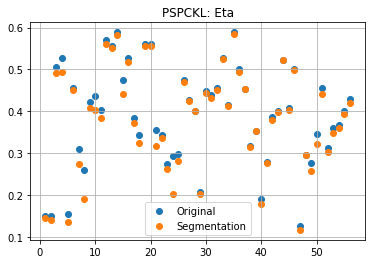

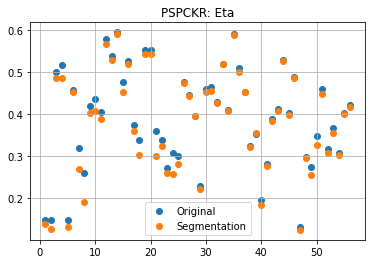

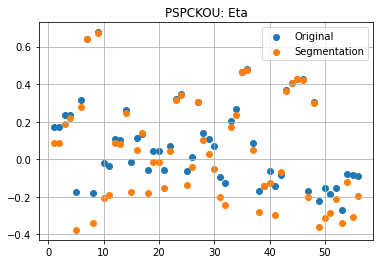

In [9]:
col_names = ['PSPCKL', 'PSPCKR', 'PSPCKOU']
for col in col_names:

    plt.plot()
    plt.title(str(col + ': Eta'))
    plt.scatter(np.arange(1,57), np.array(eta_cols_orig[col]))
    plt.scatter(np.arange(1,57), np.array(eta_cols_pred[col]))
    plt.legend(['Original', 'Segmentation'])
    plt.grid()    
    plt.show()

## Computing MVI (Generalized Scaling Exponent) for Temperature variables
## For Original time series vs Segmented time series (using Interval Halving)

In [10]:
location = 'Temperature_data.xlsx'
sheet_to_df_map = pd.read_excel(location, sheet_name = None)

In [12]:
col_names = ['TBLDC', 'TBLDL', 'TBLDR']

frac_tbldc = [0.061, 0.061, 0.035, 0.035, 0.061, 0.061, 0.035, 0.061, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, \
               0.035, 0.061, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, \
               0.035, 0.035, 0.035, 0.035, 0.035, 0.061, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.061, 0.035, \
               0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.061, 0.035, 0.061, 0.035, 0.035]

frac_tbldl = [0.087, 0.087, 0.087, 0.087, 0.061, 0.035, 0.061, 0.087, 0.061, 0.087, 0.061, 0.035, 0.035, 0.035, 0.035, \
               0.061, 0.035, 0.035, 0.087, 0.035, 0.087, 0.035, 0.061, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, \
               0.035, 0.035, 0.061, 0.061, 0.087, 0.035, 0.035, 0.061, 0.087, 0.035, 0.035, 0.035, 0.035, 0.035, 0.035, \
               0.035, 0.035, 0.061, 0.035, 0.035, 0.087, 0.061, 0.061, 0.061, 0.035, 0.035]

frac_tbldr = [0.035, 0.14, 0.087, 0.061, 0.035, 0.035, 0.061, 0.061, 0.035, 0.087, 0.035, 0.035, 0.035, 0.035, 0.035, \
                0.061, 0.035, 0.035, 0.035, 0.035, 0.061, 0.035, 0.061, 0.035, 0.035, 0.035, 0.087, 0.061, 0.035, 0.035, \
                0.061, 0.035, 0.061, 0.061, 0.087, 0.035, 0.061, 0.035, 0.061, 0.035, 0.061, 0.035, 0.035, 0.061, 0.087, \
                0.035, 0.035, 0.061, 0.035, 0.035, 0.087, 0.061, 0.087, 0.035, 0.035, 0.035]

opt_fracs = {'TBLDC': frac_tbldc, 'TBLDL': frac_tbldl, 'TBLDR': frac_tbldr}

eta_orig, eta_pred = dict(), dict()

for col in col_names:
    eta_orig[col], eta_pred[col] = list(), list()

count = 1

for sheet_ind, sheet_name in enumerate(sheet_to_df_map):
    df = sheet_to_df_map[sheet_name]
    for col in col_names:
        process_data = df[col].dropna().to_numpy()
        len_data = process_data.shape[0]
        err_data = np.var(process_data)
    
        model = Modified_Interval_Halving(noise_err = opt_fracs[col][sheet_ind]*err_data, min_window_len = 100, \
                                          title = str(sheet_name + ": " + col), suppress_print = True)
        
        model.train_model(process_data)
        process_data_pred = model.pred_data()
            
        alpha_orig_val, eta_orig_val = Scaling_Exponents(process_data)
        eta_orig[col].append(eta_orig_val)
        
        alpha_pred_val, eta_pred_val = Scaling_Exponents(process_data_pred)
        eta_pred[col].append(eta_pred_val)
        
        print('Done {}'.format(count))
        count += 1

Done 1
Done 2
Done 3
Done 4
Done 5
Done 6
Done 7
Done 8
Done 9
Done 10
Done 11
Done 12
Done 13
Done 14
Done 15
Done 16
Done 17
Done 18
Done 19
Done 20
Done 21
Done 22
Done 23
Done 24
Done 25
Done 26
Done 27
Done 28
Done 29
Done 30
Done 31
Done 32
Done 33
Done 34
Done 35
Done 36
Done 37
Done 38
Done 39
Done 40
Done 41
Done 42
Done 43
Done 44
Done 45
Done 46
Done 47
Done 48
Done 49
Done 50
Done 51
Done 52
Done 53
Done 54
Done 55
Done 56
Done 57
Done 58
Done 59
Done 60
Done 61
Done 62
Done 63
Done 64
Done 65
Done 66
Done 67
Done 68
Done 69
Done 70
Done 71
Done 72
Done 73
Done 74
Done 75
Done 76
Done 77
Done 78
Done 79
Done 80
Done 81
Done 82
Done 83
Done 84
Done 85
Done 86
Done 87
Done 88
Done 89
Done 90
Done 91
Done 92
Done 93
Done 94
Done 95
Done 96
Done 97
Done 98
Done 99
Done 100
Done 101
Done 102
Done 103
Done 104
Done 105
Done 106
Done 107
Done 108
Done 109
Done 110
Done 111
Done 112
Done 113
Done 114
Done 115
Done 116
Done 117
Done 118
Done 119
Done 120
Done 121
Done 122
Done 123
D

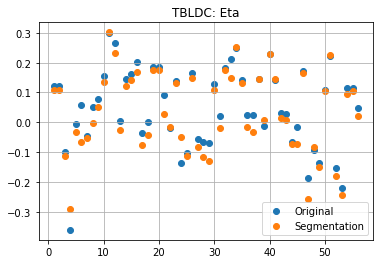

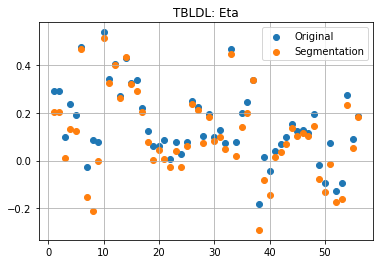

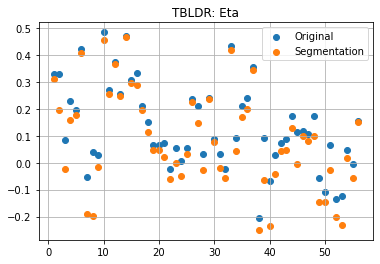

In [13]:
col_names = ['TBLDC', 'TBLDL', 'TBLDR']
for col in col_names:
    plt.figure()
    plt.title(str(col + ': Eta'))
    plt.scatter(np.arange(1,57), np.array(eta_orig[col]))
    plt.scatter(np.arange(1,57), np.array(eta_pred[col]))
    plt.legend(['Original', 'Segmentation'])
    plt.grid()